In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2FwdXJ2YW5ha2FkZS9HaXRodWIvc2Vjb25kLWRyYWZ0cw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/apurvanakade/miniconda3/lib/python3.12/importlib/_bootstrap.py": 1708117302.8894389, "/Users/apurvanakade/miniconda3/lib/python3.12/importlib/_bootstrap_external.py": 1708117302.895673, "/Users/apurvanakade/miniconda3/lib/python3.12/zipimport.py": 1708117300.842618, "/Users/apurvanakade/miniconda3/lib/python3.12/codecs.py": 1708117300.2231953, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/aliases.py": 1708117301.4904184, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/__init__.py": 1708117301.4862745, "/Users/apurvanakade/miniconda3/lib/python3.12/encodings/utf_8.py": 1708117302.0979323, "/Users/apurvanakade/miniconda3/lib/python3.12/abc.py": 1708117300.1248448, "/Users/apurvanakade/miniconda3/lib/python3.12/io.py": 1708117300.4300423, "/Users/apurvanakade/miniconda3/lib/python3.12/stat.py": 1708117300.6806324, "/Users/apurvanakade/miniconda3/lib/python3.12/_collections_abc.py": 1708117300.0486746, "/Users/apurvanakade/miniconda3/lib/python3.12/genericpath.

/var/folders/2y/zsgtjj415jdb0d4y2b_wx7th0000gn/T/ipykernel_51041/1975497035.py:25: DeprecationWarning:

`set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`



In [2]:
import matplotlib.pyplot as plt
import numpy as np

def fibonacci_cycle(n):
    """
    Find the smallest k such that F_k ≡ 0 (mod n), where F_k is the k-th Fibonacci number.
    This is called the entry point or rank of apparition of n in the Fibonacci sequence.
    
    Args:
        n: The modulus
    
    Returns:
        The smallest k such that n divides F_k
    """
    if n == 1:
        return 1  # F_1 = 1 ≡ 0 (mod 1)
    
    if n == 2:
        return 3  # F_3 = 2 ≡ 0 (mod 2)
    
    # Start with F_0 = 0, F_1 = 1
    prev, curr = 0, 1
    
    # Check F_0 first (but we typically skip k=0)
    # Generate Fibonacci numbers until we find one divisible by n
    for k in range(1, 6 * n + 1):  # Upper bound
        if curr % n == 0:
            return k
        prev, curr = curr, (prev + curr) % n
    
    return -1  # Should never reach here for valid input

def calculate_fibonacci_cycles(max_n=100):
    """
    Calculate the Fibonacci cycles for all integers from 1 to max_n.
    
    Args:
        max_n: Maximum value of n to compute
        
    Returns:
        tuple: (n_values, cycles)
    """
    n_values = list(range(1, max_n + 1))
    cycles = [fibonacci_cycle(n) for n in n_values]
    return cycles


def find_equal_cycles(n_values, cycles):
    """
    Find all values of n where cycle(n) == n
    
    Args:
        m: Maximum value of n to compute
        cycles: List of α(n)
        
    Returns:
        List of n values where α(n) = n
    """
    equal_points = [n for n, ep in zip(n_values, cycles) if ep == n]
    return equal_points

n = 10000
m = 1000

cycles = calculate_fibonacci_cycles(n)

In [3]:
equal_points = find_equal_cycles(range(1, n + 1), cycles)
# Find and print all n where α(n) = n
print(f"Values of n where α(n) = n (up to {n}):")
print(equal_points)

Values of n where α(n) = n (up to 10000):
[1, 5, 12, 25, 60, 125, 300, 625, 1500, 3125, 7500]


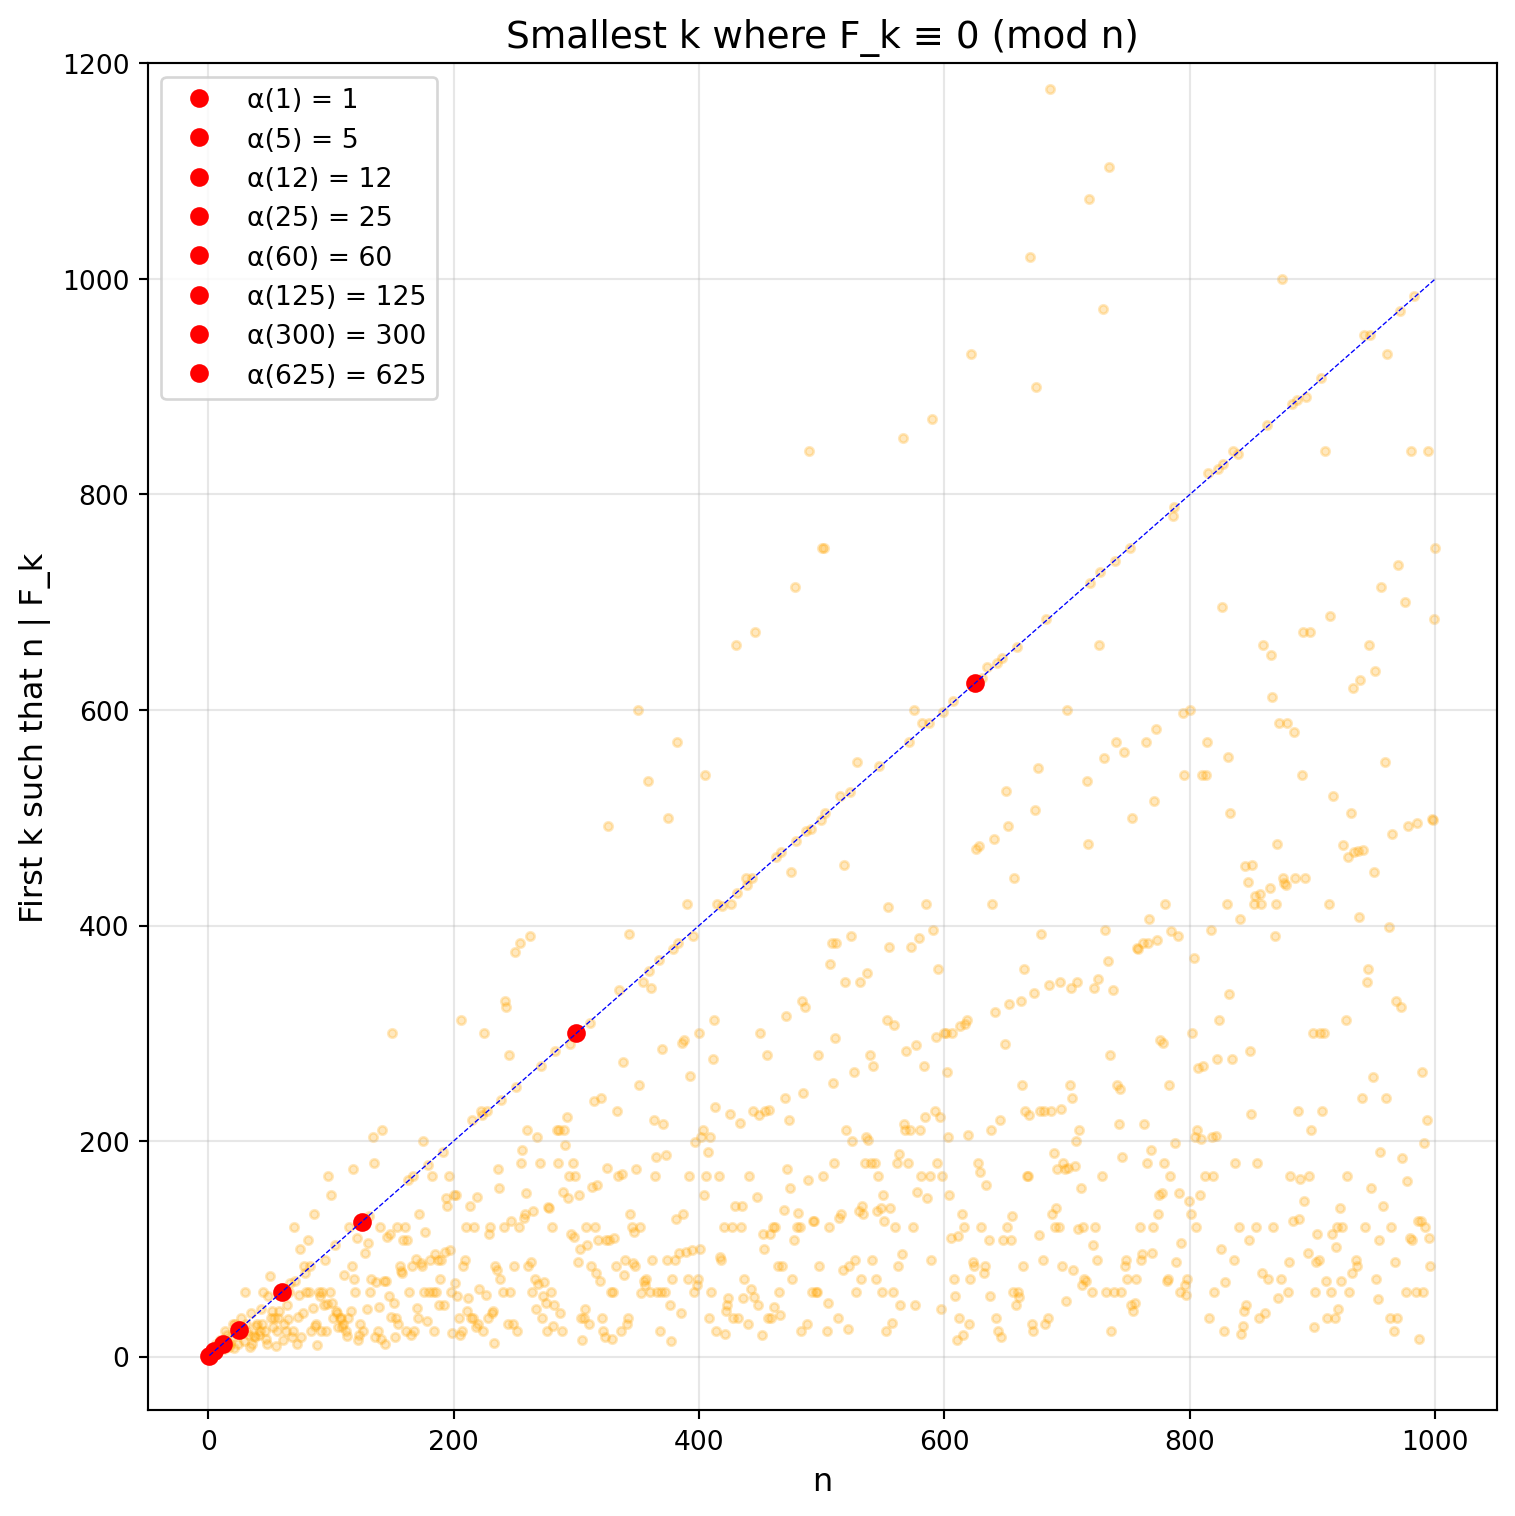

In [4]:
def plot_fibonacci_cycles(m, cycles, equal_points):
    """
    Plot the Fibonacci cycles
    
    Args:
        n_values: List of n values
        cycles: List of α(n) values
    """
    plt.figure(figsize=(8, 8))
    plt.scatter(range(1, m+1), cycles[:m], c='orange', s=10, alpha=0.25)

    plt.xlabel('n', fontsize=12)
    plt.ylabel('First k such that n | F_k', fontsize=12)
    plt.title('Smallest k where F_k ≡ 0 (mod n)', fontsize=14)
    plt.ylim(-50, 1200)
    plt.grid(True, alpha=0.3)

    # truncate equal_points to m
    equal_points = [n for n in equal_points if n <= m]

    # Add vertical lines for equal points
    for ep in equal_points:
        plt.plot(ep, ep, 'ro', label=f'α({ep}) = {ep}')

    # Add horizontal line at y = x
    plt.plot(range(1, m + 1), range(1, m + 1), 'b--', linewidth=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot the cycles
plot_fibonacci_cycles(m, cycles, equal_points)

In [5]:
def find_ratios(cycles):
    """
    Find the ratio n / α(n) for each n.
    
    Args:
        cycles: List of α(n) values

    Returns:
        List of ratios n / α(n)
    """
    ratios = [n / ep if ep != 0 else 0 for n, ep in zip(range(1, len(cycles) + 1), cycles)]
    return ratios

ratios = find_ratios(cycles)

In [6]:
def find_integers_with_ratio(ratios, k):
    """
    Find all integers n such that n / α(n) = k.
    
    Args:
        ratios: List of ratios n / α(n)
        k: The ratio to check
        
    Returns:
        List of integers n such that n / α(n) = k
    """
    return [n for n, ratio in zip(range(1, len(ratios) + 1), ratios) if ratio == k] 

k_values = set(ratios)
integer_ratios = {k: find_integers_with_ratio(ratios, k) for k in k_values}

import pandas as pd

# Prepare data for the table
table_data = []
for k, integers in integer_ratios.items():
  # if len(integers) > 1:
  table_data.append({
    'n / α(n)': k, 
    'count': len(integers),
    'n values': ', '.join(map(str, integers))
    })

# Create and display the table
df = pd.DataFrame(table_data)

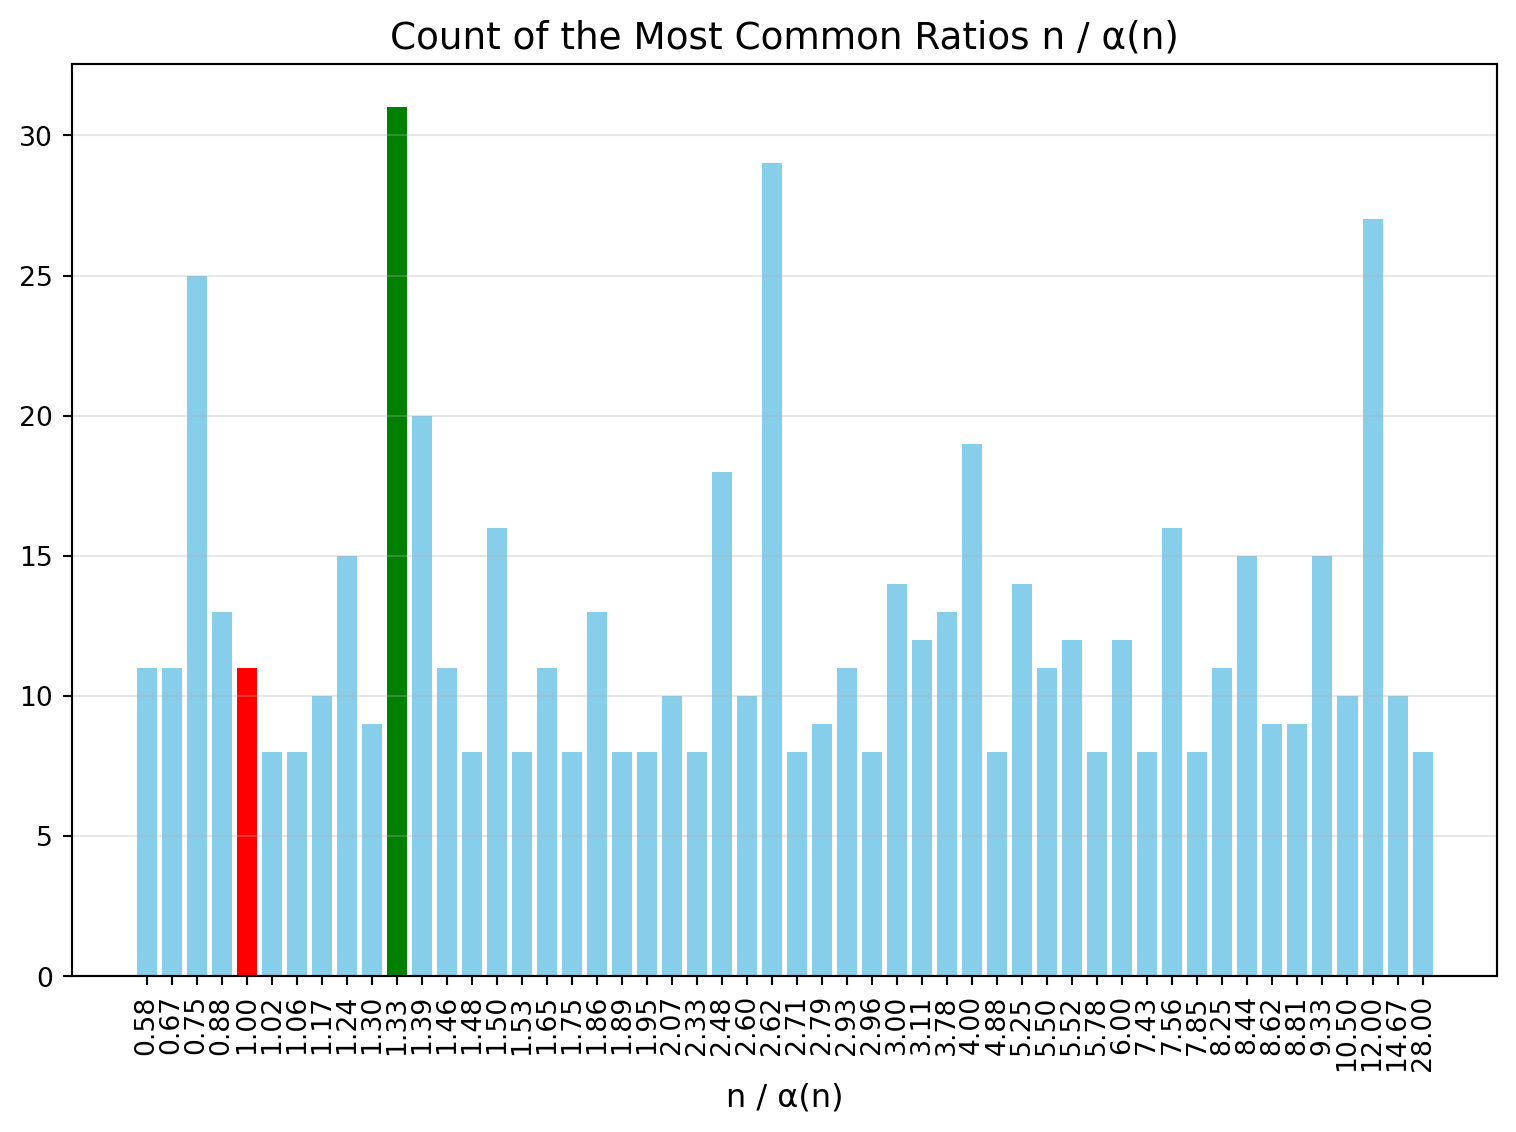

In [7]:
df_most_common = df[df['count'] > 7].sort_values(by='n / α(n)', ascending=True)

# bar chart of most common ratios
plt.figure(figsize=(8, 6))
plt.bar(df_most_common['n / α(n)'].apply(lambda x: f"{x:.2f}"), df_most_common['count'], color='skyblue')
# add a red bar at ratio 1
plt.bar('1.00', df_most_common[df_most_common['n / α(n)'] == 1]['count'].values[0], color='red', label='Ratio 1')
# add a green bar at ratio 4/3
plt.bar('1.33', df_most_common[df_most_common['n / α(n)'] == 4/3]['count'].values[0], color='green', label='Ratio 4/3')
plt.xlabel('n / α(n)', fontsize=12)
plt.ylabel('')
plt.title('Count of the Most Common Ratios n / α(n)', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# sort df by count
df = df.sort_values(by='count', ascending=False)

# print(df.to_markdown(index=False))
print(df.head(100).to_markdown(index=False))

|   n / α(n) |   count | n values                                                                                                                                                            |
|-----------:|--------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|   1.33333  |      31 | 8, 16, 32, 40, 64, 80, 128, 160, 200, 256, 320, 400, 512, 640, 800, 1000, 1024, 1280, 1600, 2000, 2048, 2560, 3200, 4000, 4096, 5000, 5120, 6400, 8000, 8192, 10000 |
|   2.625    |      29 | 21, 63, 105, 147, 189, 315, 441, 525, 567, 735, 945, 1029, 1323, 1575, 1701, 2205, 2625, 2835, 3087, 3675, 3969, 4725, 5103, 5145, 6615, 7203, 7875, 8505, 9261     |
|  12        |      27 | 144, 288, 432, 576, 720, 864, 1152, 1296, 1440, 1728, 2160, 2304, 2592, 2880, 3456, 3600, 3888, 4320, 4608, 5184, 5760, 6480, 6912, 7200, 7776, 8640, 9216          |
|   0.75     |      25 | 3, 9, 15, 27, 45, 75